### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [1]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

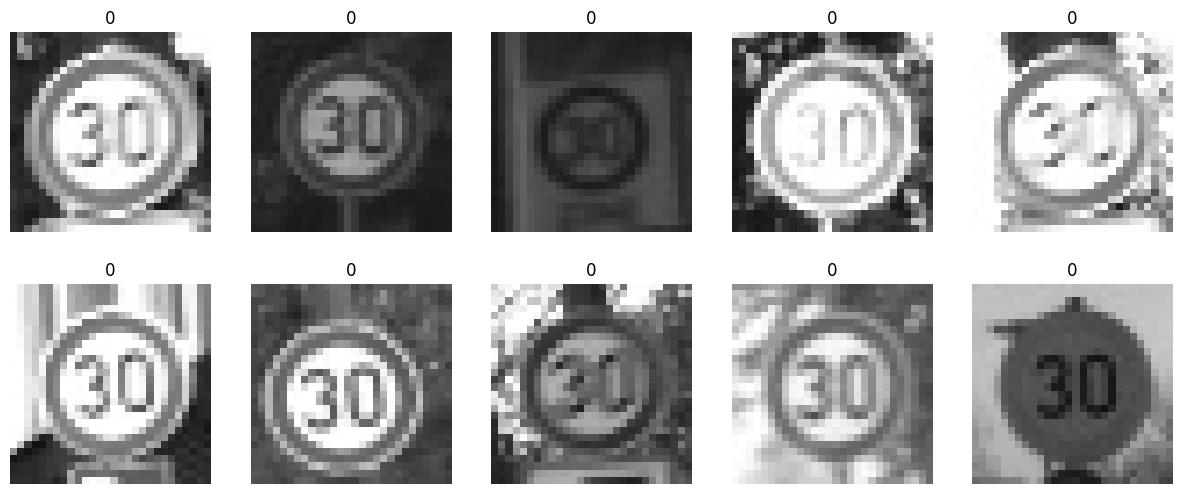

In [2]:
folder = r'..\data\subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

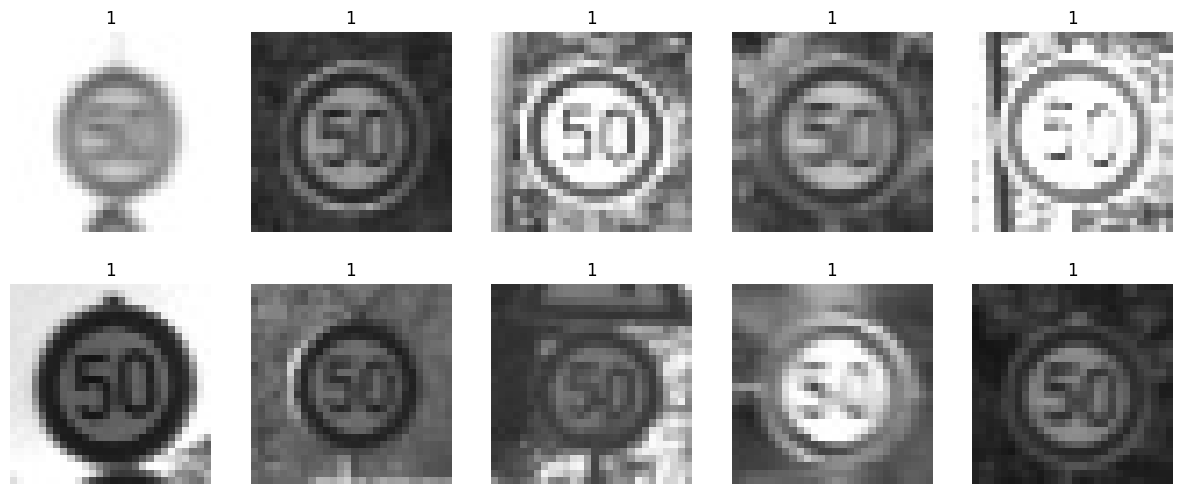

In [3]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [4]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [5]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [6]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)
    
pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 1.0522165298461914


Or, you know, just let make use of our friend numpy :-)

In [7]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.01899862289428711


Before the training, let's again have a look at some raqndom samples from our dataset.

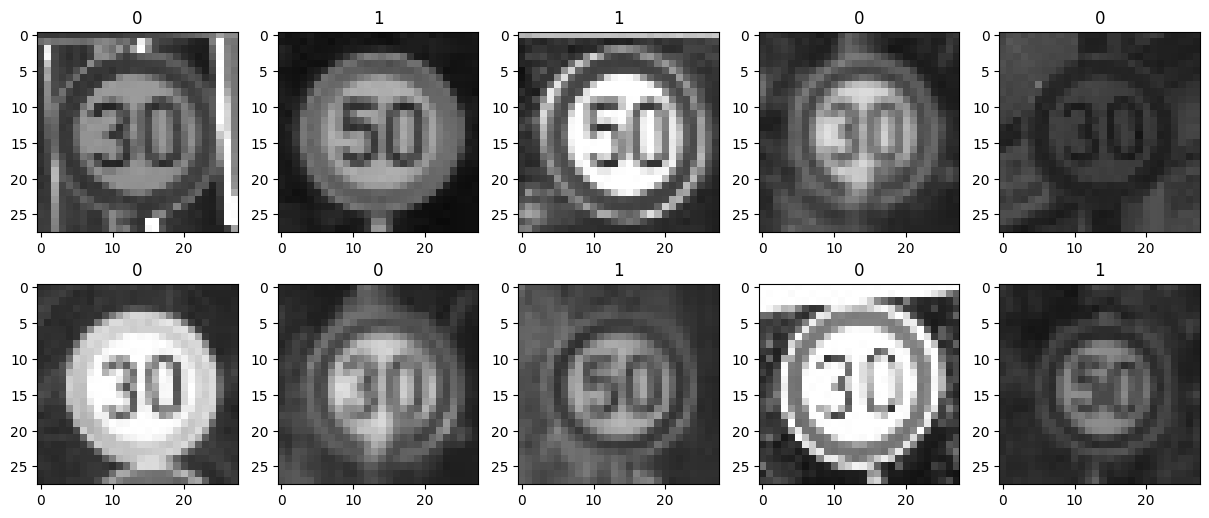

In [8]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [9]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [10]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [12]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [13]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2634
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1932
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1564
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1435
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1253
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1173
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1098
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1017
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0988
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0960


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

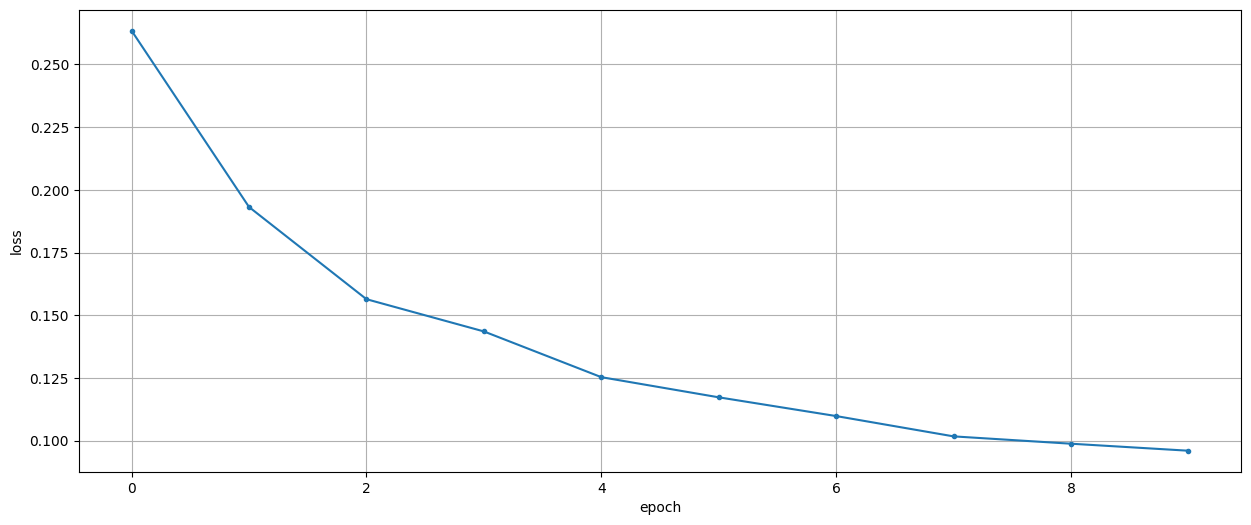

In [14]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.42578417] [0.42578417]


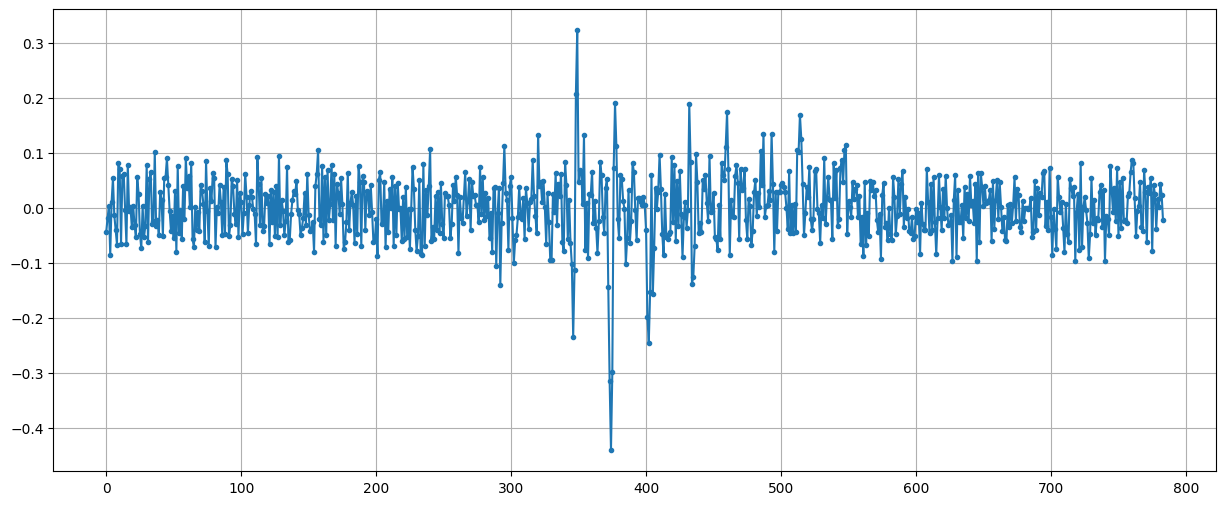

In [15]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [16]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.1890482]] 0


In [17]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step


In [18]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9304250559284116


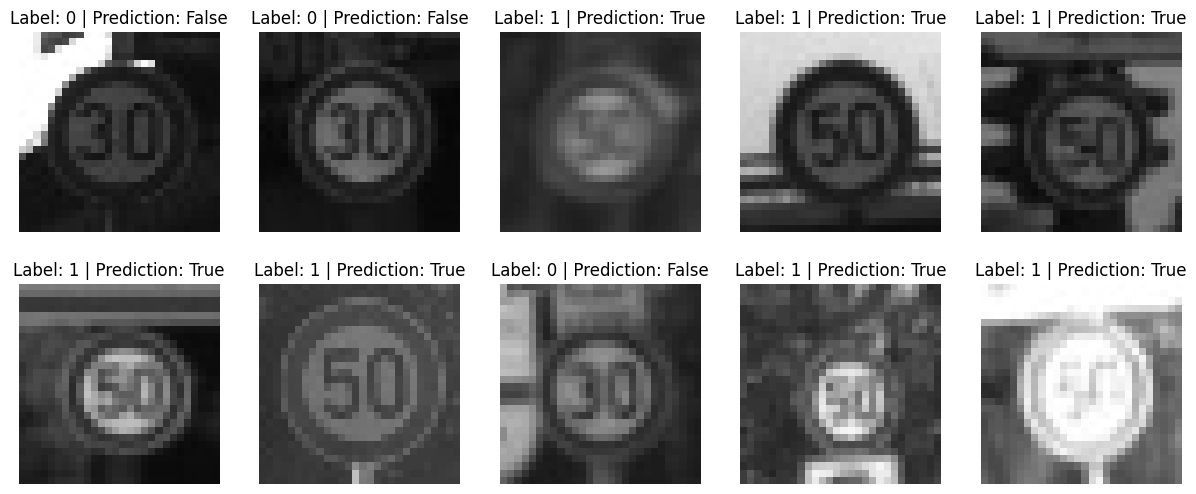

In [19]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)


Step 3: Improve Accuracy with a More Complex Model

In [28]:
# Build a new model with a hidden layer
inputs_improved = Input(shape=(pixels.shape[1],))
x_improved = Dense(128, activation="relu")(inputs_improved) # Added a hidden layer with ReLU activation
outputs_improved = Dense(1, activation="linear")(x_improved)
model_improved = Model(inputs_improved, outputs_improved)

model_improved.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compile and Train the improved model.
model_improved.compile(optimizer ='adam', loss = 'mean_squared_error')
history_improved = model_improved.fit(pixels, labels, epochs=20, batch_size=8)

Epoch 1/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0497
Epoch 2/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0464
Epoch 3/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0441
Epoch 4/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0462
Epoch 5/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0433
Epoch 6/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0429
Epoch 7/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0414
Epoch 8/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0400
Epoch 9/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0432
Epoch 10/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0390
Epoch 11/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0413
Epoch 12/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0372
Epoch 13/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0355
Epoch 14/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0387
Epoch 15/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

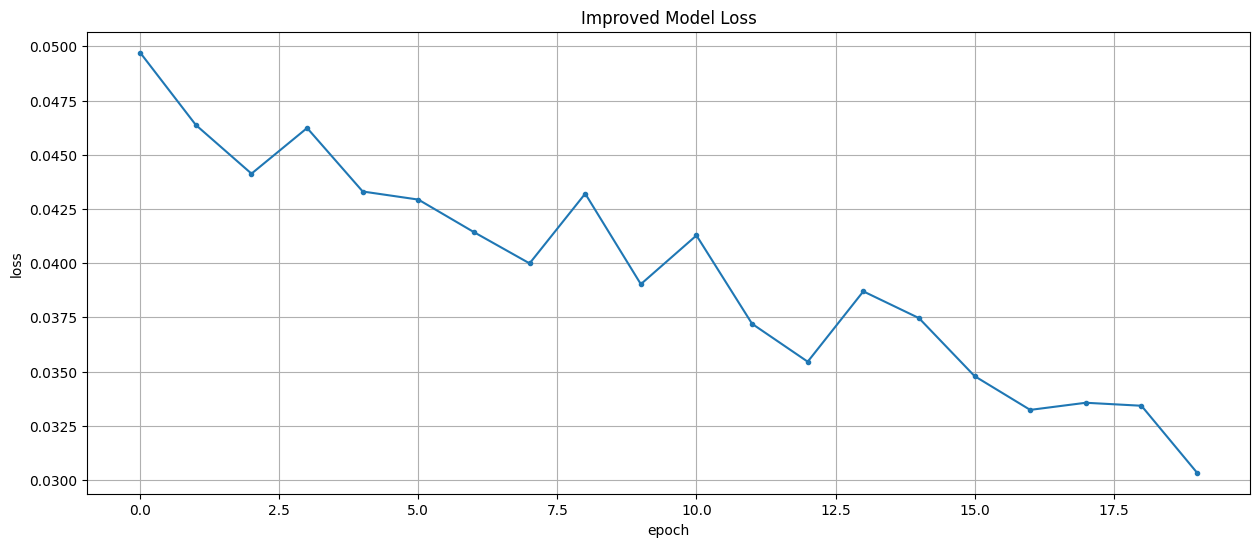

In [39]:
# Visualize the training loss for the improved model.

# Plot training history
h_improved = history_improved.history
epochs_improved = range(len(h_improved['loss']))
plt.plot(epochs_improved, h_improved['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')
plt.title('Improved Model Loss')
plt.show()

In [41]:
# Evaluate the performance of the improved model.

predictions_improved = model_improved.predict(pixels).squeeze()
predictions_improved = predictions_improved > 0.5

correct_improved = 0
for prediction, label in zip(predictions_improved, labels):
    if prediction == label:
        correct_improved = correct_improved + 1

print('Accuracy (Improved Model)', correct_improved/len(labels))

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy (Improved Model) 0.9903803131991051


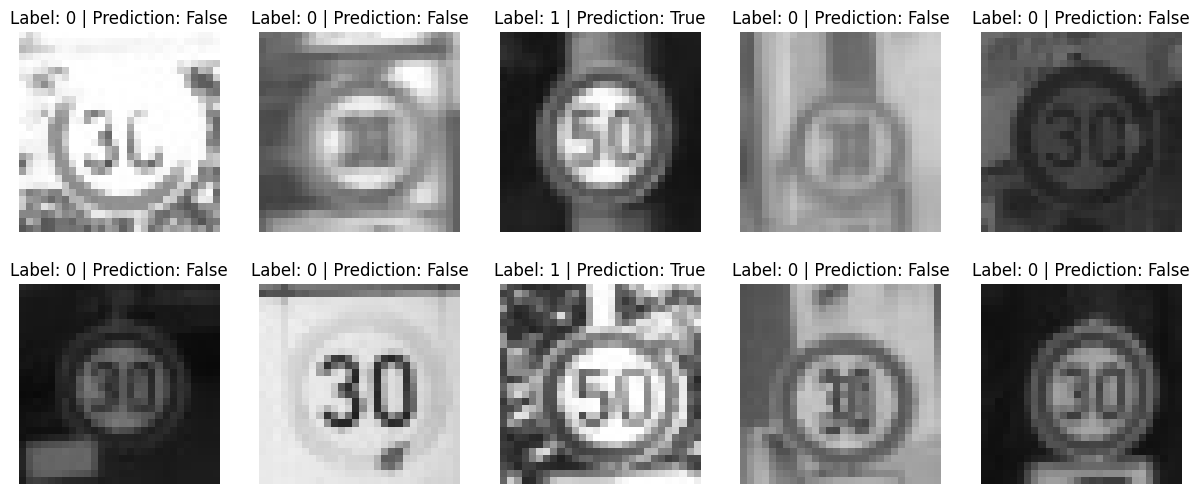

In [42]:
# Visualize some predictions from the improved model.

for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions_improved[idx]))
    plt.axis(False)
plt.show()

### What is the maximum accuracy you can achieve?

I was able to achieve 99% accuracy just adding one hidden layer with 128 neurons.
